# Section 22: Style transfer

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as T

import requests
from PIL import Image
from io import BytesIO

## Transferring the screaming bathtub

In [2]:
vgg_net_weights = torchvision.models.VGG19_Weights.DEFAULT
vgg_net = torchvision.models.vgg19(weights=vgg_net_weights)

for parameters in vgg_net.parameters():
    parameters.requires_grad = False
    
vgg_net.eval();

In [3]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

vgg_net.to(device);

In [4]:
url = 'https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg'
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (compatible; ImageLoader/1.0)"})
content_image = np.array(Image.open(BytesIO(response.content)), dtype=np.uint8)

url = 'https://upload.wikimedia.org/wikipedia/commons/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg'
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (compatible; ImageLoader/1.0)"})
style_image = np.array(Image.open(BytesIO(response.content)), dtype=np.uint8)

target_image = np.random.randint(low=0, high=255, size=content_image.shape, dtype=np.uint8)

print(content_image.shape)
print(style_image.shape)
print(target_image.shape)

(1675, 3000, 3)
(4000, 3223, 3)
(1675, 3000, 3)


In [5]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.Normalize(mean=[.485, .456, .406], std=[.229, .224, .225])
])

content_image = transform(content_image).unsqueeze(0).to(device)
style_image = transform(style_image).unsqueeze(0).to(device)
target_image = transform(target_image).unsqueeze(0).to(device)

print(content_image.shape)
print(style_image.shape)
print(target_image.shape)

torch.Size([1, 3, 256, 458])
torch.Size([1, 3, 317, 256])
torch.Size([1, 3, 256, 458])


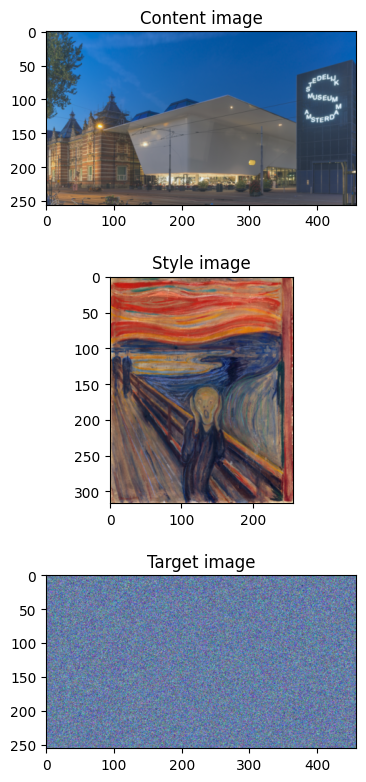

In [6]:
images = [content_image, style_image, target_image]
image_names = ['content', 'style', 'target']

_, axs = plt.subplots(3, 1, figsize=(4, 10))

for i, ax in enumerate(axs):
    image = images[i].cpu().squeeze().numpy().transpose((1, 2, 0))
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    ax.imshow(image)
    ax.set_title(f"{image_names[i].title()} image")
    
plt.show()

In [7]:
def get_feature_map_activations(image_local, net_local):
    feature_maps_local = []
    feature_names_local = []
    convolution_layer_index = 0
    
    for layer_index_local in range(len(net_local.features)):
        image_local = net_local.features[layer_index_local](image_local)
        
        if 'Conv2d' in str(net_local.features[layer_index_local]):
            feature_maps_local.append(image_local)
            feature_names_local.append(f"ConvLayer{str(convolution_layer_index)}")
            
            convolution_layer_index += 1
            
    return feature_maps_local, feature_names_local

In [8]:
def get_gram_matrix(feature_map_activation_local):
    _, channels, height, width = feature_map_activation_local.shape
    feature_map_activation_local = feature_map_activation_local.reshape(channels, height * width)
    
    return torch.mm(feature_map_activation_local, feature_map_activation_local.t() / (channels * height * width))

In [9]:
content_feature_maps, content_feature_names = get_feature_map_activations(content_image, vgg_net)

for i in range(len(content_feature_names)):
    print(f"Feature map \"{content_feature_names[i]}\" is size {content_feature_maps[i].shape}")

Feature map "ConvLayer0" is size torch.Size([1, 64, 256, 458])
Feature map "ConvLayer1" is size torch.Size([1, 64, 256, 458])
Feature map "ConvLayer2" is size torch.Size([1, 128, 128, 229])
Feature map "ConvLayer3" is size torch.Size([1, 128, 128, 229])
Feature map "ConvLayer4" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer5" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer6" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer7" is size torch.Size([1, 256, 64, 114])
Feature map "ConvLayer8" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer9" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer10" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer11" is size torch.Size([1, 512, 32, 57])
Feature map "ConvLayer12" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer13" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer14" is size torch.Size([1, 512, 16, 28])
Feature map "ConvLayer15" is size torch.Size([1, 512, 1

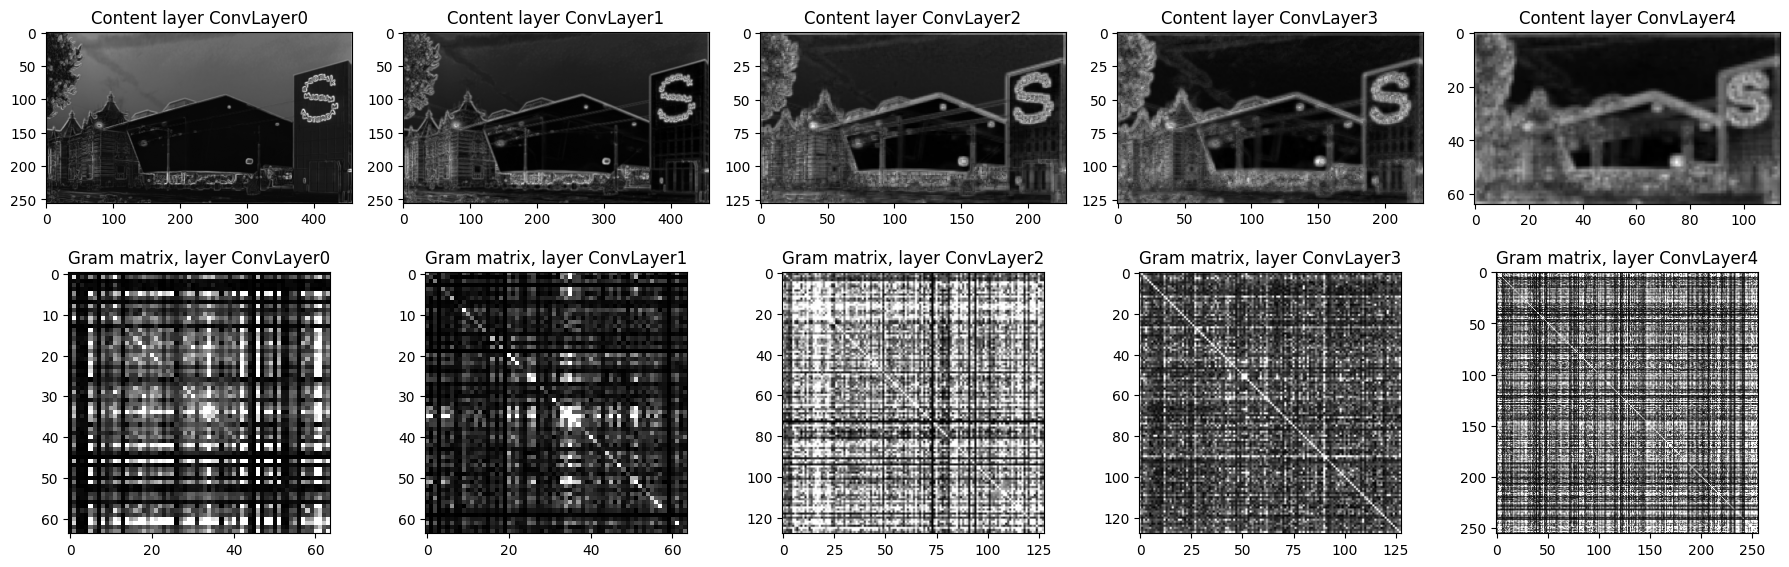

In [10]:
_, axs = plt.subplots(2, 5, figsize=(18, 6))

for i in range(5):
    image = np.mean(content_feature_maps[i].cpu().squeeze().numpy(), axis=0)
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    axs[0, i].imshow(image, cmap='gray')
    axs[0, i].set_title(f"Content layer {content_feature_names[i]}")

    image = get_gram_matrix(content_feature_maps[i]).cpu().numpy()
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    axs[1, i].imshow(image, cmap='gray', vmax=.1)
    axs[1, i].set_title(f"Gram matrix, layer {content_feature_names[i]}")

plt.tight_layout()
plt.show()

In [11]:
style_feature_maps, style_feature_names = get_feature_map_activations(style_image, vgg_net)

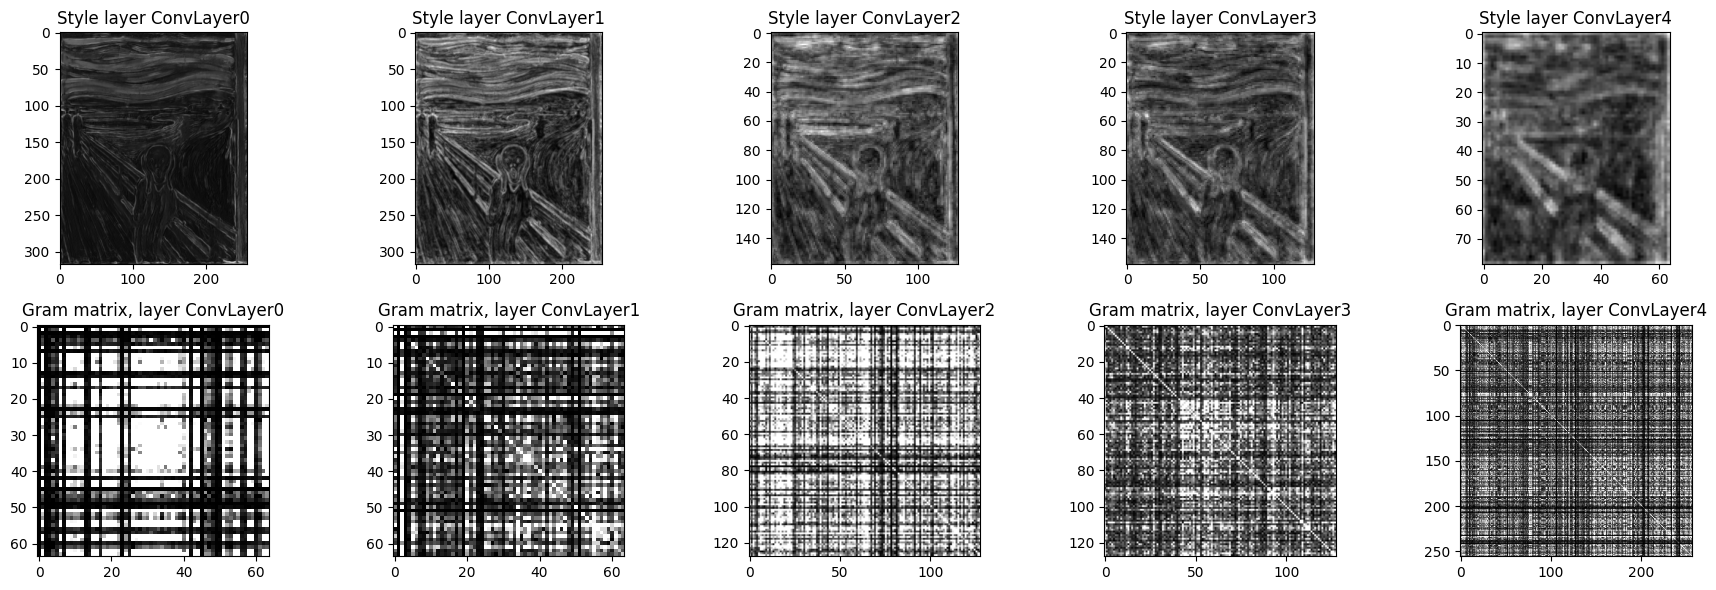

In [12]:
_, axs = plt.subplots(2, 5, figsize=(18, 6))

for i in range(5):
    image = np.mean(style_feature_maps[i].cpu().squeeze().numpy(), axis=0)
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    axs[0, i].imshow(image, cmap='gray')
    axs[0, i].set_title(f"Style layer {style_feature_names[i]}")

    image = get_gram_matrix(style_feature_maps[i]).cpu().numpy()
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    axs[1, i].imshow(image, cmap='gray', vmax=.1)
    axs[1, i].set_title(f"Gram matrix, layer {style_feature_names[i]}")

plt.tight_layout()
plt.show()

In [13]:
content_layers = ['ConvLayer1', 'ConvLayer4']
style_layers = ['ConvLayer1', 'ConvLayer2', 'ConvLayer3', 'ConvLayer4', 'ConvLayer5']
style_weights = [1, .5, .5, .2, .1]

In [14]:
target_image.requires_grad = True
style_scaling = 1e6
epochs_nr = 1500
optimizer = torch.optim.RMSprop([target_image], lr=.005)

for epoch in range(epochs_nr):
    target_feature_maps, target_feature_names = get_feature_map_activations(target_image, vgg_net)
    style_loss = 0
    content_loss = 0
    
    for layer_index in range(len(target_feature_names)):
        if target_feature_names[layer_index] in content_layers:
            content_loss += torch.mean((target_feature_maps[layer_index] - content_feature_maps[layer_index]) ** 2)
            
        if target_feature_names[layer_index] in style_layers:
            target_gram_matrix = get_gram_matrix(target_feature_maps[layer_index])
            style_gram_matrix = get_gram_matrix(style_feature_maps[layer_index])
            style_weight = style_weights[style_layers.index(target_feature_names[layer_index])]
            
            style_loss += torch.mean((target_gram_matrix - style_gram_matrix) ** 2) * style_weight
            
    combined_loss = style_scaling * style_loss + content_loss
    
    optimizer.zero_grad()
    combined_loss.backward()
    optimizer.step()

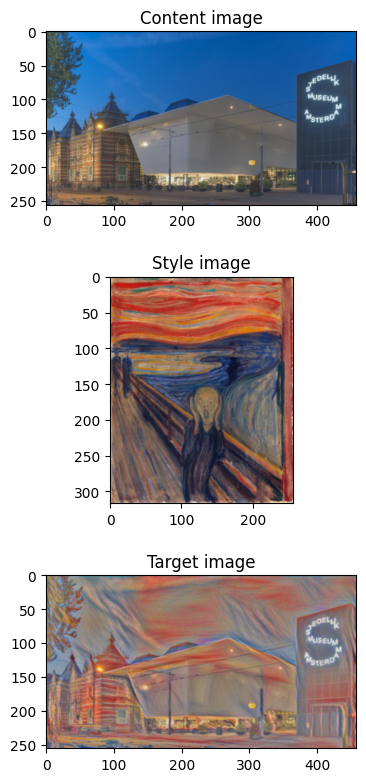

In [15]:
target_image = torch.sigmoid(target_image).detach()
images = [content_image, style_image, target_image]

_, axs = plt.subplots(3, 1, figsize=(4, 10))

for i, ax in enumerate(axs):
    image = images[i].cpu().squeeze().numpy().transpose((1, 2, 0))
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    ax.imshow(image)
    ax.set_title(f"{image_names[i].title()} image")
    
plt.show()

## CodeChallenge: Style transfer with AlexNet

In [16]:
alex_net_weights = torchvision.models.AlexNet_Weights.DEFAULT
alex_net = torchvision.models.alexnet(weights=alex_net_weights)

for parameters in alex_net.parameters():
    parameters.requires_grad = False

alex_net.eval()
alex_net.to(device);

In [17]:
url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Orange_tabby_cat_sitting_on_fallen_leaves-Hisashi-01A.jpg/1280px-Orange_tabby_cat_sitting_on_fallen_leaves-Hisashi-01A.jpg'
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (compatible; ImageLoader/1.0)"})
content_image = np.array(Image.open(BytesIO(response.content)), dtype=np.uint8)

url = 'https://upload.wikimedia.org/wikipedia/commons/6/66/VanGogh-starry_night_ballance1.jpg'
response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (compatible; ImageLoader/1.0)"})
style_image = np.array(Image.open(BytesIO(response.content)), dtype=np.uint8)

target_image = np.random.randint(low=0, high=255, size=content_image.shape, dtype=np.uint8)

print(content_image.shape)
print(style_image.shape)
print(target_image.shape)

(1707, 1280, 3)
(1500, 1879, 3)
(1707, 1280, 3)


In [18]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize(227),
    T.Normalize(mean=[.485, .456, .406], std=[.229, .224, .225])
])

content_image = transform(content_image).unsqueeze(0).to(device)
style_image = transform(style_image).unsqueeze(0).to(device)
target_image = transform(target_image).unsqueeze(0).to(device)

print(content_image.shape)
print(style_image.shape)
print(target_image.shape)

torch.Size([1, 3, 302, 227])
torch.Size([1, 3, 227, 284])
torch.Size([1, 3, 302, 227])


In [19]:
content_feature_maps, content_feature_names = get_feature_map_activations(content_image, alex_net)

for i in range(len(content_feature_names)):
    print(f"Feature map \"{content_feature_names[i]}\" is size {content_feature_maps[i].shape}")

Feature map "ConvLayer0" is size torch.Size([1, 64, 74, 56])
Feature map "ConvLayer1" is size torch.Size([1, 192, 36, 27])
Feature map "ConvLayer2" is size torch.Size([1, 384, 17, 13])
Feature map "ConvLayer3" is size torch.Size([1, 256, 17, 13])
Feature map "ConvLayer4" is size torch.Size([1, 256, 17, 13])


In [20]:
style_feature_maps, style_feature_names = get_feature_map_activations(style_image, alex_net)

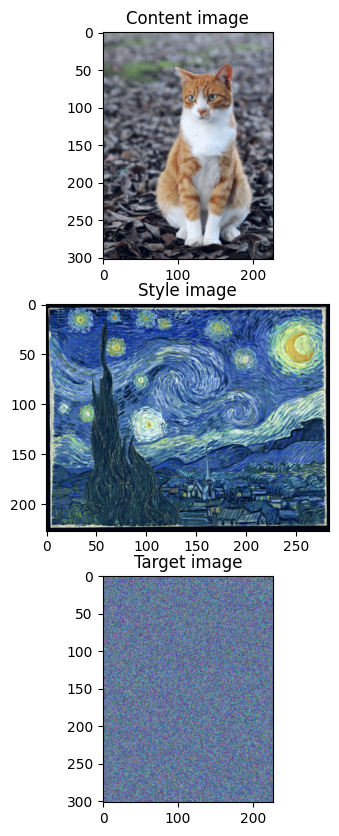

In [21]:
images = [content_image, style_image, target_image]
image_names = ['content', 'style', 'target']

_, axs = plt.subplots(3, 1, figsize=(4, 10))

for i, ax in enumerate(axs):
    image = images[i].cpu().squeeze().numpy().transpose((1, 2, 0))
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    ax.imshow(image)
    ax.set_title(f"{image_names[i].title()} image")
    
plt.show()

In [22]:
content_layers = ['ConvLayer0']
style_layers = ['ConvLayer0', 'ConvLayer1', 'ConvLayer2', 'ConvLayer3', 'ConvLayer4']
style_weights = [1, .8, .6, .4, .2]

In [23]:
target_image.requires_grad = True
style_scaling = 1e4
epochs_nr = 1500
optimizer = torch.optim.RMSprop([target_image], lr=.001)

for epoch in range(epochs_nr):
    target_feature_maps, target_feature_names = get_feature_map_activations(target_image, alex_net)
    style_loss = 0
    content_loss = 0
    
    for layer_index in range(len(target_feature_names)):
        if target_feature_names[layer_index] in content_layers:
            content_loss += torch.mean((target_feature_maps[layer_index] - content_feature_maps[layer_index]) ** 2)
            
        if target_feature_names[layer_index] in style_layers:
            target_gram_matrix = get_gram_matrix(target_feature_maps[layer_index])
            style_gram_matrix = get_gram_matrix(style_feature_maps[layer_index])
            style_weight = style_weights[style_layers.index(target_feature_names[layer_index])]
            
            style_loss += torch.mean((target_gram_matrix - style_gram_matrix) ** 2) * style_weight
            
    combined_loss = style_scaling * style_loss + content_loss
    
    optimizer.zero_grad()
    combined_loss.backward()
    optimizer.step()

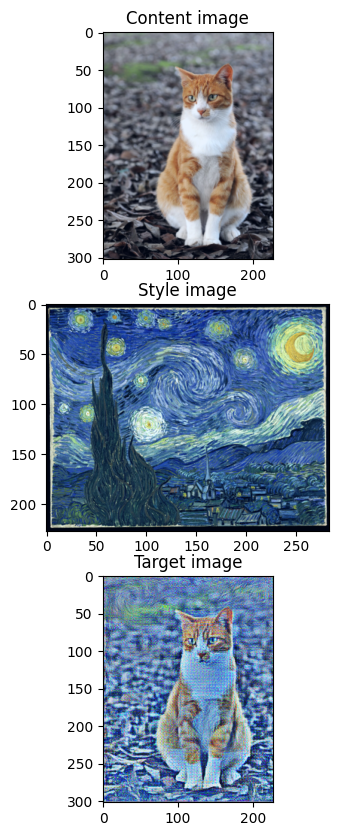

In [24]:
target_image = torch.sigmoid(target_image).detach()
images = [content_image, style_image, target_image]

_, axs = plt.subplots(3, 1, figsize=(4, 10))

for i, ax in enumerate(axs):
    image = images[i].cpu().squeeze().numpy().transpose((1, 2, 0))
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    ax.imshow(image)
    ax.set_title(f"{image_names[i].title()} image")
    
plt.show()